In [1]:
# Load data first if not already loaded
import pandas as pd


loan_core   = pd.read_csv('../csvs/loan_core.csv',           nrows=None, low_memory=False)
borrower    = pd.read_csv('../csvs/borrower_profile.csv',    nrows=None, low_memory=False)
credit      = pd.read_csv('../csvs/credit_history.csv',      nrows=None, low_memory=False)
balances    = pd.read_csv('../csvs/account_balances.csv',    nrows=None, low_memory=False)
activity    = pd.read_csv('../csvs/account_activity.csv',    nrows=None, low_memory=False)

# Diagnose: check for duplicate 'id' and columns in each table
for name, tbl in [('loan_core', loan_core), ('borrower', borrower),
                   ('credit', credit), ('balances', balances), ('activity', activity)]:
    n = len(tbl)
    has_id = 'id' in tbl.columns
    nuniq = tbl['id'].nunique() if has_id else 0
    ratio = f"{n/nuniq:.2f}x" if nuniq > 0 else "N/A"
    print(f"{name:20s} -> rows: {n:>10,}  has_id: {has_id}  unique_ids: {nuniq:>10,}  dup_ratio: {ratio}")
    print(f"  columns: {list(tbl.columns[:10])}")
    print()

loan_core            -> rows:  2,260,668  has_id: True  unique_ids:          0  dup_ratio: N/A
  columns: ['id', 'term', 'installment', 'grade', 'loan_status', 'disbursement_method']

borrower             -> rows:  2,260,668  has_id: True  unique_ids:          0  dup_ratio: N/A
  columns: ['id', 'annual_inc_joint', 'emp_title', 'application_type', 'purpose', 'title', 'zip_code']

credit               -> rows:  2,260,668  has_id: True  unique_ids:          0  dup_ratio: N/A
  columns: ['id', 'sec_app_earliest_cr_line', 'mths_since_last_major_derog', 'chargeoff_within_12_mths', 'collections_12_mths_ex_med', 'pub_rec_bankruptcies', 'tax_liens', 'pct_tl_nvr_dlq']

balances             -> rows:  2,260,668  has_id: True  unique_ids:          0  dup_ratio: N/A
  columns: ['id', 'revol_bal_joint', 'tot_cur_bal', 'tot_hi_cred_lim', 'total_rev_hi_lim', 'total_il_high_credit_limit', 'total_bal_il', 'all_util', 'il_util', 'avg_cur_bal']

activity             -> rows:  2,260,668  has_id: True  uniq

In [2]:
# Check what the 'id' column actually contains
print("loan_core['id'] dtype:", loan_core['id'].dtype)
print("loan_core['id'] nulls:", loan_core['id'].isna().sum())
print("loan_core['id'] sample:\n", loan_core['id'].head(10))
print()
# Check if there's an index or other candidate key
print("loan_core index:", loan_core.index[:5].tolist())
print()
# Check all column names for potential join keys
for name, tbl in [('loan_core', loan_core), ('borrower', borrower)]:
    print(f"{name} columns: {list(tbl.columns)}")
    print()

loan_core['id'] dtype: float64
loan_core['id'] nulls: 2260668
loan_core['id'] sample:
 0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
5   NaN
6   NaN
7   NaN
8   NaN
9   NaN
Name: id, dtype: float64

loan_core index: [0, 1, 2, 3, 4]

loan_core columns: ['id', 'term', 'installment', 'grade', 'loan_status', 'disbursement_method']

borrower columns: ['id', 'annual_inc_joint', 'emp_title', 'application_type', 'purpose', 'title', 'zip_code']



In [3]:
# ══════════════════════════════════════════════════════════════
# LENDING CLUB — MASTER LOADER
# Run this first. Everything else depends on df_master
# ══════════════════════════════════════════════════════════════

import gc
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── STEP 1: Load each CSV
# All 6 files have the same 2,260,668 rows (split column-wise from one dataset).
# The 'id' column is entirely NaN, so we join by row position (pd.concat axis=1).

NROWS = None  # Set to 200000 for fast testing, None for full data

loan_core   = pd.read_csv('../csvs/loan_core.csv',           nrows=NROWS, low_memory=False)
borrower    = pd.read_csv('../csvs/borrower_profile.csv',    nrows=NROWS, low_memory=False)
credit      = pd.read_csv('../csvs/credit_history.csv',      nrows=NROWS, low_memory=False)
balances    = pd.read_csv('../csvs/account_balances.csv',     nrows=NROWS, low_memory=False)
activity    = pd.read_csv('../csvs/account_activity.csv',     nrows=NROWS, low_memory=False)
extra       = pd.read_csv('../csvs/extra_unassigned.csv',     nrows=NROWS, low_memory=False)

# ── STEP 2: Positional concat (drop duplicate 'id' columns — all NaN anyway)
tables = [loan_core,
          borrower.drop(columns='id', errors='ignore'),
          credit.drop(columns='id', errors='ignore'),
          balances.drop(columns='id', errors='ignore'),
          activity.drop(columns='id', errors='ignore'),
          extra]

df = pd.concat(tables, axis=1)

# Drop the all-NaN 'id' column unconditionally
df = df.drop(columns='id', errors='ignore')

# Guard against duplicate columns after concat
dupes = df.columns[df.columns.duplicated()].tolist()
if dupes:
    print(f"WARNING: dropping duplicate columns: {dupes}")
    df = df.loc[:, ~df.columns.duplicated(keep='first')]

# Free memory from intermediate frames
del loan_core, borrower, credit, balances, activity, extra, tables
gc.collect()

print(f"Master dataframe: {df.shape[0]:,} rows x {df.shape[1]} columns")

# ── STEP 3: Parse dates and create year column
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y', errors='coerce')
df['issue_year'] = df['issue_d'].dt.year

# ── STEP 4: Create binary default flag (the target variable)
# Fully Paid = good, Charged Off / Default = bad
# Current / Late loans are ambiguous — exclude for outcome analysis
DEFAULT_STATUSES = ['Charged Off', 'Default',
                    'Does not meet the credit policy. Status:Charged Off']
PAID_STATUSES    = ['Fully Paid',
                    'Does not meet the credit policy. Status:Fully Paid']

df['is_default'] = np.where(df['loan_status'].isin(DEFAULT_STATUSES), 1,
                   np.where(df['loan_status'].isin(PAID_STATUSES),    0, np.nan))

df_closed = df[df['is_default'].notna()].copy()
print(f"Closed loans (paid or defaulted): {len(df_closed):,}")
print(f"Overall default rate: {df_closed['is_default'].mean():.1%}")
print(f"\nYear range: {df['issue_year'].min()} - {df['issue_year'].max()}")
print(f"\nGrade distribution:\n{df_closed['grade'].value_counts().sort_index()}")
print(f"\nLoan status distribution:\n{df['loan_status'].value_counts()}")

# ── STEP 5: Maturity bias warning
# Loans issued in recent years (2016-2018) are disproportionately
# still "Current" — their default rates appear lower simply because
# they haven't had time to default yet. Flag this for analysis.
for yr in sorted(df['issue_year'].dropna().unique()):
    yr_all = df[df['issue_year'] == yr]
    yr_closed = yr_all[yr_all['is_default'].notna()]
    pct_closed = len(yr_closed) / len(yr_all) * 100 if len(yr_all) > 0 else 0
    if pct_closed < 80:
        print(f"  MATURITY WARNING: {int(yr)} — only {pct_closed:.0f}% of loans are closed")

Master dataframe: 2,260,668 rows x 142 columns
Closed loans (paid or defaulted): 1,306,387
Overall default rate: 20.1%

Year range: 2007 - 2018

Grade distribution:
grade
A    226343
B    380512
C    370566
D    195979
E     92110
F     31732
G      9145
Name: count, dtype: int64

Loan status distribution:
loan_status
Fully Paid                                             1041952
Current                                                 919695
Charged Off                                             261655
Late (31-120 days)                                       21897
In Grace Period                                           8952
Late (16-30 days)                                         3737
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     31
Name: count, dtype: int64
  MATURITY WARNING: 2016 — only 63% of loans are closed
  MATURITY WARNING: 2017 — only

In [4]:
# Check maturity rates for all years
print("=== LOAN MATURITY CHECK ===")
maturity = df.groupby('issue_year').apply(
    lambda x: pd.Series({
        'total_loans': len(x),
        'closed_loans': x['is_default'].notna().sum(),
        'pct_closed': x['is_default'].notna().mean() * 100,
        'observed_default_rate': x['is_default'].mean() * 100
    })
).round(1)
print(maturity)

# Safe threshold — only use years where 80%+ loans are resolved
print("\n=== RECOMMENDATION ===")
safe_years = maturity[maturity['pct_closed'] >= 80].index.tolist()
print(f"Years with 80%+ maturity: {safe_years}")
print(f"Years to EXCLUDE: {[y for y in maturity.index if y not in safe_years]}")

=== LOAN MATURITY CHECK ===
            total_loans  closed_loans  pct_closed  observed_default_rate
issue_year                                                              
2007              603.0         603.0       100.0                   26.2
2008             2393.0        2393.0       100.0                   20.7
2009             5281.0        5281.0       100.0                   13.7
2010            12537.0       12537.0       100.0                   14.0
2011            21721.0       21721.0       100.0                   15.2
2012            53367.0       53367.0       100.0                   16.2
2013           134814.0      134793.0       100.0                   15.6
2014           235629.0      221468.0        94.0                   18.5
2015           421095.0      373412.0        88.7                   20.2
2016           434407.0      274711.0        63.2                   24.3
2017           443579.0      158910.0        35.8                   22.9
2018           495242.0

In [5]:
# ── COLUMN AUDIT — run this once, share output with whole team
print("=== COLUMNS AVAILABLE ===")
print(df_closed.columns.tolist())

print("\n=== KEY COLUMN NULL % ===")
key_cols = ['grade','int_rate','fico_range_low','fico_range_high',
            'annual_inc','dti','addr_state','verification_status',
            'emp_length','revol_util','delinq_2yrs','inq_last_6mths',
            'purpose','home_ownership','term','loan_amnt']
for c in key_cols:
    if c in df_closed.columns:
        pct = df_closed[c].isna().mean()*100
        print(f"  {c:<30} {pct:.1f}% null")
    else:
        print(f"  {c:<30} ❌ NOT FOUND")

print("\n=== GRADE DISTRIBUTION ===")
print(df_closed['grade'].value_counts().sort_index())

print("\n=== DEFAULT RATE BY GRADE ===")
print(df_closed.groupby('grade')['is_default'].agg(['mean','count'])
      .rename(columns={'mean':'default_rate','count':'n_loans'})
      .assign(default_rate=lambda x: x['default_rate'].map('{:.1%}'.format)))

print("\n=== DEFAULT RATE BY YEAR ===")
print(df_closed.groupby('issue_year')['is_default'].agg(['mean','count'])
      .rename(columns={'mean':'default_rate','count':'n_loans'})
      .assign(default_rate=lambda x: x['default_rate'].map('{:.1%}'.format)))

=== COLUMNS AVAILABLE ===
['term', 'installment', 'grade', 'loan_status', 'disbursement_method', 'annual_inc_joint', 'emp_title', 'application_type', 'purpose', 'title', 'zip_code', 'sec_app_earliest_cr_line', 'mths_since_last_major_derog', 'chargeoff_within_12_mths', 'collections_12_mths_ex_med', 'pub_rec_bankruptcies', 'tax_liens', 'pct_tl_nvr_dlq', 'revol_bal_joint', 'tot_cur_bal', 'tot_hi_cred_lim', 'total_rev_hi_lim', 'total_il_high_credit_limit', 'total_bal_il', 'all_util', 'il_util', 'avg_cur_bal', 'max_bal_bc', 'inq_last_12m', 'inq_fi', 'open_acc_6m', 'open_il_12m', 'open_il_24m', 'open_rv_12m', 'open_rv_24m', 'num_rev_accts', 'num_op_rev_tl', 'num_bc_tl', 'num_bc_sats', 'num_sats', 'num_tl_op_past_12m', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_rev_tl_bal_gt_0', 'num_accts_ever_120_pd', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'ver

In [6]:
# Verify your flag is correct
print(df_closed.groupby(['loan_status','is_default']).size())
# Should show: Fully Paid → 0, Charged Off → 1, Default → 1

loan_status                                          is_default
Charged Off                                          1.0            261655
Default                                              1.0                31
Does not meet the credit policy. Status:Charged Off  1.0               761
Does not meet the credit policy. Status:Fully Paid   0.0              1988
Fully Paid                                           0.0           1041952
dtype: int64


In [7]:
# Run this to find where FICO lives
loan_core   = pd.read_csv('../csvs/loan_core.csv',           nrows=NROWS, low_memory=False)
borrower    = pd.read_csv('../csvs/borrower_profile.csv',    nrows=NROWS, low_memory=False)
credit      = pd.read_csv('../csvs/credit_history.csv',      nrows=NROWS, low_memory=False)
balances    = pd.read_csv('../csvs/account_balances.csv',     nrows=NROWS, low_memory=False)
activity    = pd.read_csv('../csvs/account_activity.csv',     nrows=NROWS, low_memory=False)
extra       = pd.read_csv('../csvs/extra_unassigned.csv',     nrows=NROWS, low_memory=False)
for table_name, table_df in [('loan_core', loan_core), 
                               ('borrower', borrower),
                               ('credit', credit),
                               ('balances', balances),
                               ('activity', activity)]:
    fico_cols = [c for c in table_df.columns if 'fico' in c.lower()]
    if fico_cols:
        print(f"FICO found in {table_name}: {fico_cols}")

In [ ]:
# ── ANALYSIS DATASET (excludes 2016,2017,2018 — incomplete outcomes)
df_analysis = df_closed[df_closed['issue_year'] <= 2015].copy()

# Clean int_rate (stored as "13.56%" string in some versions)
df_analysis['int_rate_clean'] = pd.to_numeric(
    df_analysis['int_rate'].astype(str).str.replace('%','').str.strip(),
    errors='coerce')

print(f"Analysis dataset: {len(df_analysis):,} rows")
print(f"Years: {df_analysis['issue_year'].min()} – {df_analysis['issue_year'].max()}")
print(f"Int rate sample: {df_analysis['int_rate_clean'].describe()}")

Analysis dataset: 825,575 rows
Years: 2007 – 2015
Int rate sample: count    825575.000000
mean         13.135962
std           4.395043
min           5.320000
25%           9.760000
50%          12.990000
75%          15.880000
max          28.990000
Name: int_rate_clean, dtype: float64


In [9]:
import os

# List all CSV files you have
csv_files = [f for f in os.listdir('.') if f.endswith('.csv')]
print("All CSV files:", csv_files)

# Search each one for FICO columns
for filename in csv_files:
    try:
        # Only read first row — super fast, no memory cost
        temp = pd.read_csv(filename, nrows=1, low_memory=False)
        fico_cols = [c for c in temp.columns if 'fico' in c.lower()]
        if fico_cols:
            print(f"\n✅ FICO found in: {filename}")
            print(f"   Columns: {fico_cols}")
        else:
            print(f"   ❌ {filename} — no FICO")
    except Exception as e:
        print(f"   ⚠️ Could not read {filename}: {e}")

All CSV files: []


In [10]:
# ── STEP 1: See what's in both missing files
for filename in ['../csvs/extra_unassigned.csv', '../csvs/platform_metadata.csv']:
    temp = pd.read_csv(filename, nrows=3, low_memory=False)
    print(f"\n=== {filename} ===")
    print(f"Columns ({len(temp.columns)}): {temp.columns.tolist()}")
    print(f"Sample rows:")
    print(temp.head(3))


=== ../csvs/extra_unassigned.csv ===
Columns (94): ['member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'pymnt_plan', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'policy_code', 'dti_joint', 'verification_status_joint', 'acc_now_delinq', 'tot_coll_amt', 'open_act_il', 'mths_since_rcnt_il', 'total_cu_tl', 'acc_open_past_24mths', 'bc_open_to_buy', 'bc_util', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_si

In [11]:
print(f"Shape: {df_analysis.shape}")
print(f"\nKey columns confirmed present:")
must_have = ['grade','loan_amnt','annual_inc','dti','revol_util',
             'delinq_2yrs','inq_last_6mths','addr_state',
             'verification_status','int_rate_clean',
             'issue_year','is_default']
for col in must_have:
    status = "✅" if col in df_analysis.columns else "❌ MISSING"
    print(f"  {status}  {col}")

Shape: (825575, 145)

Key columns confirmed present:
  ✅  grade
  ✅  loan_amnt
  ✅  annual_inc
  ✅  dti
  ✅  revol_util
  ✅  delinq_2yrs
  ✅  inq_last_6mths
  ✅  addr_state
  ✅  verification_status
  ✅  int_rate_clean
  ✅  issue_year
  ✅  is_default


In [12]:
# ══════════════════════════════════════════════════════════════
# DATA PREP: Create df_analysis from closed loans
# Apply maturity filter to avoid survivorship bias in trends
# ══════════════════════════════════════════════════════════════

df_analysis = df_closed.copy()

# int_rate is already numeric (e.g. 22.35); create clean alias
df_analysis['int_rate_clean'] = pd.to_numeric(df_analysis['int_rate'], errors='coerce')

# Filter to years with enough maturity + enough volume
# 2016-2018 loans have low closure rates -> biased default rates
# Keep only vintages where >= 80% of loans have resolved
year_closure = df.groupby('issue_year')['is_default'].apply(
    lambda x: x.notna().mean()).reset_index()
year_closure.columns = ['issue_year', 'pct_closed']
mature_years = year_closure[year_closure['pct_closed'] >= 0.80]['issue_year'].values

df_analysis = df_analysis[df_analysis['issue_year'].isin(mature_years)].copy()

# Also require minimum 500 loans per year
year_counts = df_analysis['issue_year'].value_counts()
valid_years = year_counts[year_counts >= 500].index
df_analysis = df_analysis[df_analysis['issue_year'].isin(valid_years)].copy()

print(f"df_analysis: {len(df_analysis):,} rows (maturity-filtered)")
print(f"Years retained: {sorted(df_analysis['issue_year'].unique())}")
print(f"Years dropped (immature): {sorted(set(df_closed['issue_year'].dropna().unique()) - set(df_analysis['issue_year'].unique()))}")
print(f"Default rate (filtered): {df_analysis['is_default'].mean():.1%}")
print(f"\nint_rate_clean: min={df_analysis['int_rate_clean'].min():.2f}, "
      f"median={df_analysis['int_rate_clean'].median():.2f}, "
      f"max={df_analysis['int_rate_clean'].max():.2f}")

df_analysis: 825,575 rows (maturity-filtered)
Years retained: [np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015)]
Years dropped (immature): [np.int32(2016), np.int32(2017), np.int32(2018)]
Default rate (filtered): 18.5%

int_rate_clean: min=5.32, median=12.99, max=28.99


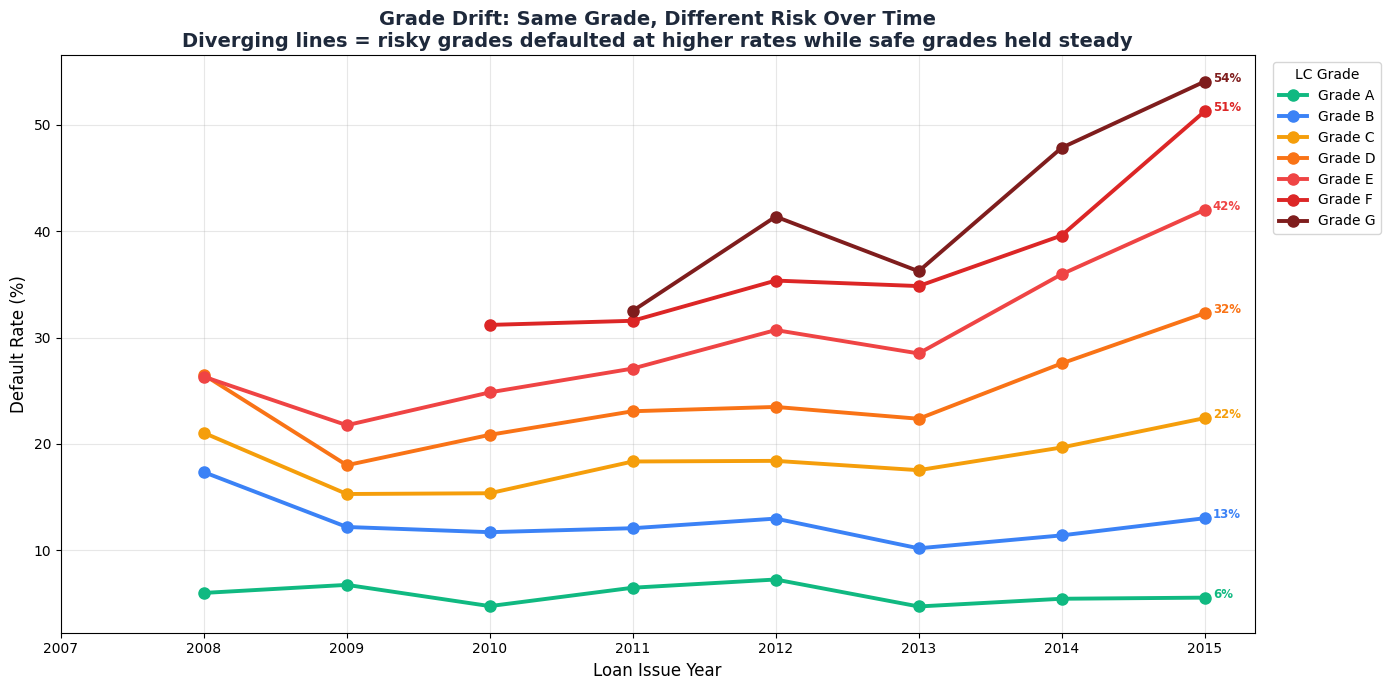


=== GRADE SPREAD BY YEAR ===
  2008: spread=20.5pp  A=6.0%  G=N/A
  2009: spread=15.0pp  A=6.7%  G=N/A
  2010: spread=26.5pp  A=4.7%  G=N/A
  2011: spread=26.0pp  A=6.5%  G=32.5%
  2012: spread=34.1pp  A=7.2%  G=41.4%
  2013: spread=31.5pp  A=4.7%  G=36.2%
  2014: spread=42.4pp  A=5.4%  G=47.9%
  2015: spread=48.6pp  A=5.5%  G=54.1%

Chart 1 saved - chart1_grade_drift.png


In [13]:
# ══════════════════════════════════════════════════════════
# ANALYSIS 1: Does Grade C in 2012 = Grade C in 2016?
# (HERO CHART — Grade Drift)
# ══════════════════════════════════════════════════════════

drift = (df_analysis
         .groupby(['issue_year','grade'])['is_default']
         .agg(default_rate='mean', n_loans='count')
         .reset_index())
drift['default_rate_pct'] = drift['default_rate'] * 100
drift = drift[drift['n_loans'] >= 200]  # filter thin cells

fig, ax = plt.subplots(figsize=(14, 7))

grades  = ['A','B','C','D','E','F','G']
colors  = ['#10b981','#3b82f6','#f59e0b','#f97316',
           '#ef4444','#dc2626','#7f1d1d']

for grade, color in zip(grades, colors):
    d = drift[drift['grade'] == grade]
    if len(d) < 3:
        continue
    ax.plot(d['issue_year'], d['default_rate_pct'],
            marker='o', label=f'Grade {grade}',
            color=color, linewidth=2.8, markersize=8)
    # Label the last point
    last = d.iloc[-1]
    ax.annotate(f"{last['default_rate_pct']:.0f}%",
                xy=(last['issue_year'], last['default_rate_pct']),
                xytext=(6, 0), textcoords='offset points',
                fontsize=8.5, color=color, fontweight='bold')

ax.set_xlabel('Loan Issue Year', fontsize=12)
ax.set_ylabel('Default Rate (%)', fontsize=12)
ax.set_title('Grade Drift: Same Grade, Different Risk Over Time\n'
             'Diverging lines = risky grades defaulted at higher rates while safe grades held steady',
             fontsize=14, fontweight='bold', color='#1e293b')
ax.legend(title='LC Grade', bbox_to_anchor=(1.01,1), loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_xticks(sorted(df_analysis['issue_year'].unique()))
plt.tight_layout()
plt.savefig('chart1_grade_drift.png', dpi=180, bbox_inches='tight',
            facecolor='white')
plt.show()

# Key stats
print("\n=== GRADE SPREAD BY YEAR ===")
for year in sorted(drift['issue_year'].unique()):
    yr = drift[drift['issue_year'] == year]
    if len(yr) < 4:
        continue
    spread = yr['default_rate_pct'].max() - yr['default_rate_pct'].min()
    a_rate = yr[yr['grade']=='A']['default_rate_pct'].values
    g_rate = yr[yr['grade']=='G']['default_rate_pct'].values
    a_str = f"{a_rate[0]:.1f}%" if len(a_rate) else "N/A"
    g_str = f"{g_rate[0]:.1f}%" if len(g_rate) else "N/A"
    print(f"  {int(year)}: spread={spread:.1f}pp  A={a_str}  G={g_str}")

print("\nChart 1 saved - chart1_grade_drift.png")

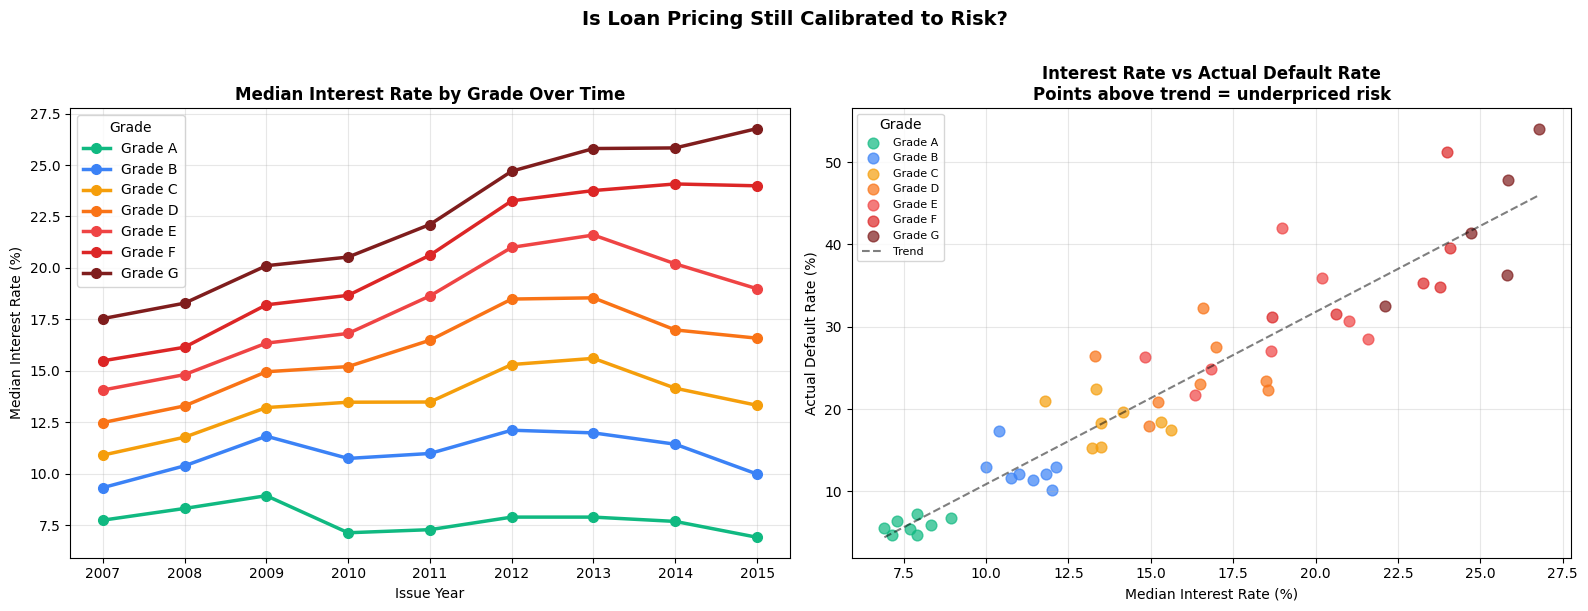

Chart 2 saved - chart2_rate_alignment.png


In [14]:
# ══════════════════════════════════════════════════════════
# ANALYSIS 2: Is pricing (int_rate) still matched to grade?
# ══════════════════════════════════════════════════════════

rate_trend = (df_analysis
              .groupby(['issue_year','grade'])['int_rate_clean']
              .median().reset_index())
rate_trend.columns = ['year','grade','median_rate']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: rate over time by grade
ax = axes[0]
for grade, color in zip(grades, colors):
    d = rate_trend[rate_trend['grade'] == grade]
    if len(d) > 0:
        ax.plot(d['year'], d['median_rate'], marker='o',
                label=f'Grade {grade}', color=color,
                linewidth=2.5, markersize=7)
ax.set_title('Median Interest Rate by Grade Over Time',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Issue Year')
ax.set_ylabel('Median Interest Rate (%)')
ax.legend(title='Grade')
ax.grid(True, alpha=0.3)

# Right: rate vs actual default — are they in sync?
ax = axes[1]
merged = drift.merge(rate_trend, left_on=['issue_year','grade'],
                     right_on=['year','grade'])
for grade, color in zip(grades, colors):
    d = merged[merged['grade'] == grade]
    if len(d) > 2:
        ax.scatter(d['median_rate'], d['default_rate_pct'],
                   color=color, alpha=0.7, s=60, label=f'Grade {grade}')

# Fit a trendline
x = merged['median_rate'].dropna()
y = merged.loc[x.index, 'default_rate_pct']
if len(x) > 10:
    coeffs = np.polyfit(x, y, 1)
    xline = np.linspace(x.min(), x.max(), 100)
    ax.plot(xline, np.polyval(coeffs, xline),
            'k--', linewidth=1.5, alpha=0.5, label='Trend')

ax.set_title('Interest Rate vs Actual Default Rate\n'
             'Points above trend = underpriced risk',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Median Interest Rate (%)')
ax.set_ylabel('Actual Default Rate (%)')
ax.legend(title='Grade', fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle('Is Loan Pricing Still Calibrated to Risk?',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('chart2_rate_alignment.png', dpi=180, bbox_inches='tight',
            facecolor='white')
plt.show()
print("Chart 2 saved - chart2_rate_alignment.png")

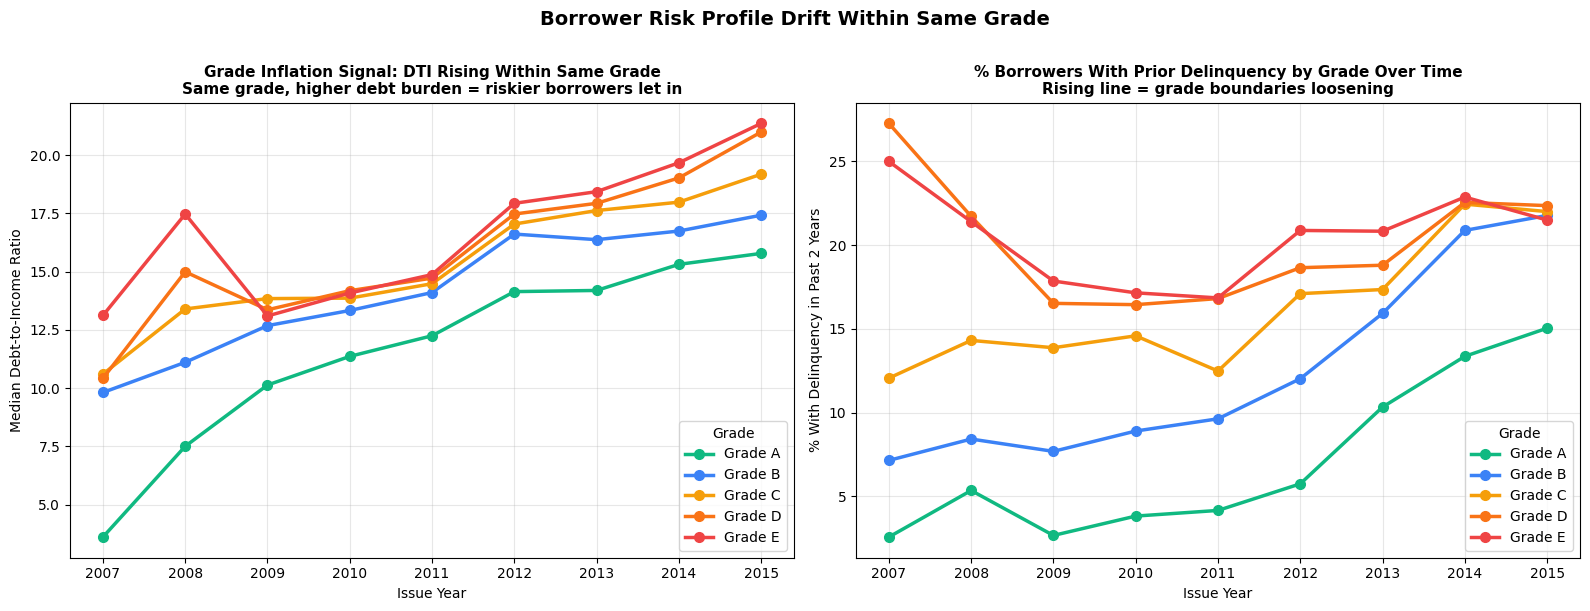

=== DTI DRIFT STATS - GRADE C ===
 year  median_dti
 2007      10.600
 2008      13.395
 2009      13.840
 2010      13.860
 2011      14.480
 2012      17.040
 2013      17.620
 2014      17.980
 2015      19.180

=== DELINQUENCY DRIFT - GRADE C ===
 year  pct_delinq_pct
 2007       12.056738
 2008       14.310345
 2009       13.872404
 2010       14.584097
 2011       12.480974
 2012       17.103158
 2013       17.349910
 2014       22.451815
 2015       22.005062

Chart 3 saved - chart3_profile_drift.png


In [15]:
# ══════════════════════════════════════════════════════════
# ANALYSIS 3: Did same-grade borrowers get riskier over time?
# DTI + Delinquency as grade inflation signals
# ══════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LEFT: Median DTI by grade over time
dti_trend = (df_analysis
             .groupby(['issue_year','grade'])['dti']
             .median().reset_index())
dti_trend.columns = ['year','grade','median_dti']

ax = axes[0]
for grade, color in zip(['A','B','C','D','E'],
                         ['#10b981','#3b82f6','#f59e0b',
                          '#f97316','#ef4444']):
    d = dti_trend[dti_trend['grade'] == grade]
    if len(d) > 2:
        ax.plot(d['year'], d['median_dti'], marker='o',
                label=f'Grade {grade}', color=color,
                linewidth=2.5, markersize=7)

ax.set_title('Grade Inflation Signal: DTI Rising Within Same Grade\n'
             'Same grade, higher debt burden = riskier borrowers let in',
             fontweight='bold', fontsize=11)
ax.set_xlabel('Issue Year')
ax.set_ylabel('Median Debt-to-Income Ratio')
ax.legend(title='Grade')
ax.grid(True, alpha=0.3)

# RIGHT: % of borrowers with delinquency by grade over time
df_analysis['has_delinq'] = (df_analysis['delinq_2yrs'] > 0).astype(int)
delinq_trend = (df_analysis
                .groupby(['issue_year','grade'])['has_delinq']
                .mean().reset_index())
delinq_trend.columns = ['year','grade','pct_delinq']
delinq_trend['pct_delinq_pct'] = delinq_trend['pct_delinq'] * 100

ax = axes[1]
for grade, color in zip(['A','B','C','D','E'],
                         ['#10b981','#3b82f6','#f59e0b',
                          '#f97316','#ef4444']):
    d = delinq_trend[delinq_trend['grade'] == grade]
    if len(d) > 2:
        ax.plot(d['year'], d['pct_delinq_pct'], marker='o',
                label=f'Grade {grade}', color=color,
                linewidth=2.5, markersize=7)

ax.set_title('% Borrowers With Prior Delinquency by Grade Over Time\n'
             'Rising line = grade boundaries loosening',
             fontweight='bold', fontsize=11)
ax.set_xlabel('Issue Year')
ax.set_ylabel('% With Delinquency in Past 2 Years')
ax.legend(title='Grade')
ax.grid(True, alpha=0.3)

plt.suptitle('Borrower Risk Profile Drift Within Same Grade',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('chart3_profile_drift.png', dpi=180,
            bbox_inches='tight', facecolor='white')
plt.show()

# Stats
print("=== DTI DRIFT STATS - GRADE C ===")
grade_c_dti = dti_trend[dti_trend['grade']=='C'].sort_values('year')
print(grade_c_dti[['year','median_dti']].to_string(index=False))

print("\n=== DELINQUENCY DRIFT - GRADE C ===")
grade_c_dlq = delinq_trend[delinq_trend['grade']=='C'].sort_values('year')
print(grade_c_dlq[['year','pct_delinq_pct']].to_string(index=False))

print("\nChart 3 saved - chart3_profile_drift.png")

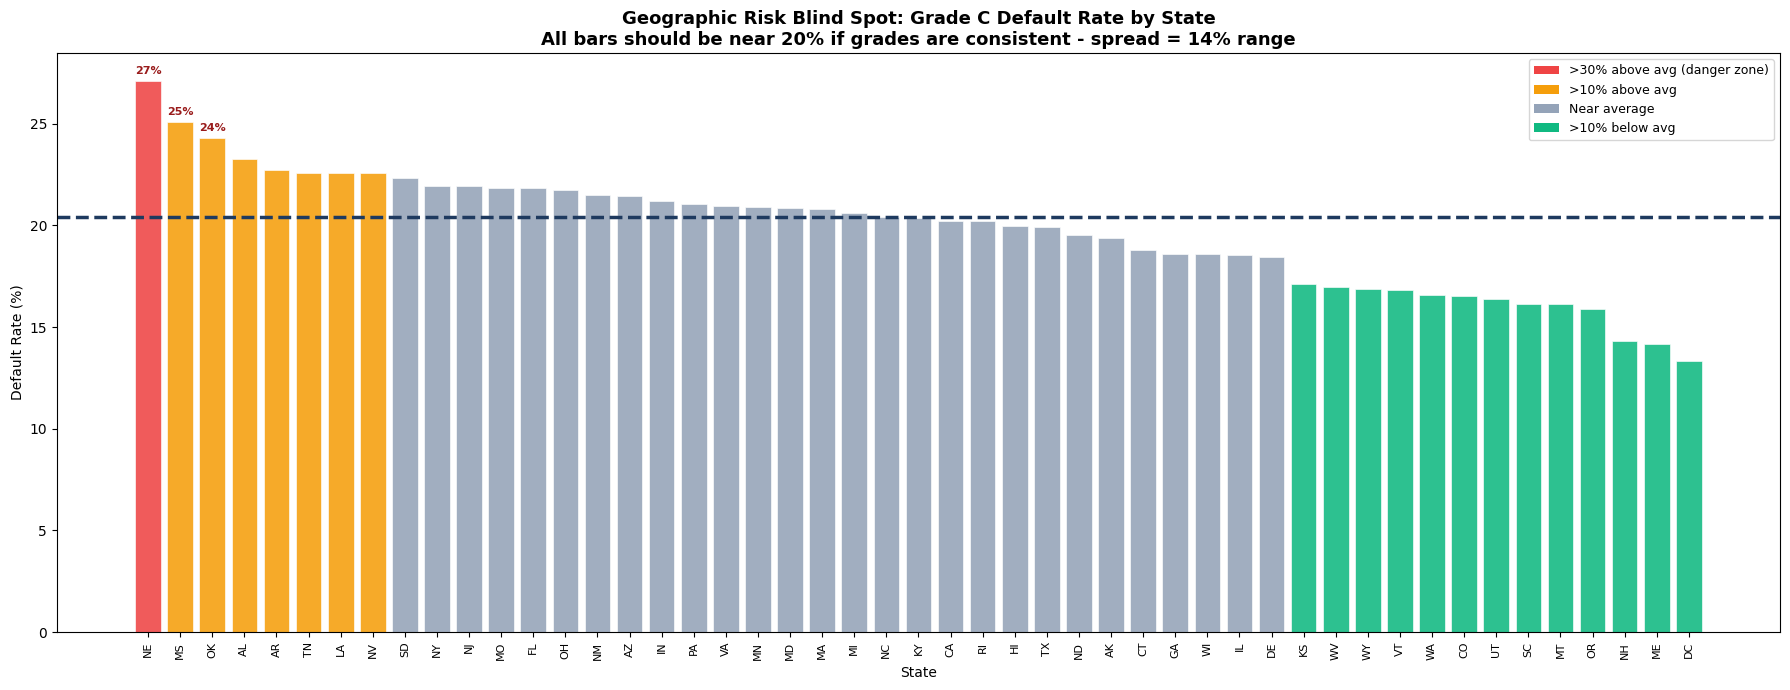

Chart 4 saved

=== GEOGRAPHIC STATS ===
Grade C overall default rate: 20.4%
State range: 13.3% - 27.1%  (spread = 13.8pp)

Top 5 highest-default states:
addr_state default_rate  n_loans
        NE        27.1%      295
        MS        25.1%     1000
        OK        24.3%     2099
        AL        23.3%     2903
        AR        22.7%     1722

Top 5 lowest-default states:
addr_state default_rate  n_loans
        MT        16.1%      639
        OR        15.9%     2776
        NH        14.3%     1021
        ME        14.2%      127
        DC        13.3%      556


In [16]:
# ══════════════════════════════════════════════════════════
# ANALYSIS 4: Within-grade default rate by state
# Grade C only — biggest volume, most stable for comparison
# ══════════════════════════════════════════════════════════

grade_c = df_analysis[df_analysis['grade'] == 'C'].copy()
state_stats = (grade_c.groupby('addr_state')['is_default']
               .agg(default_rate='mean', n_loans='count')
               .reset_index())
state_stats = state_stats[state_stats['n_loans'] >= 100].copy()
state_stats = state_stats.sort_values('default_rate', ascending=False)
overall_c   = grade_c['is_default'].mean()

fig, ax = plt.subplots(figsize=(18, 7))
bar_colors = ['#ef4444' if r > overall_c * 1.3
              else '#f59e0b' if r > overall_c * 1.1
              else '#10b981' if r < overall_c * 0.9
              else '#94a3b8'
              for r in state_stats['default_rate']]

bars = ax.bar(state_stats['addr_state'],
              state_stats['default_rate'] * 100,
              color=bar_colors, alpha=0.88,
              edgecolor='white', linewidth=0.5)

ax.axhline(y=overall_c * 100, color='#1e3a5f',
           linewidth=2.5, linestyle='--',
           label=f'Grade C average: {overall_c:.1%}')

# Annotate top 3 worst
for idx, (_, row) in enumerate(state_stats.head(3).iterrows()):
    ax.annotate(f"{row['default_rate']:.0%}",
                xy=(idx, row['default_rate']*100),
                xytext=(0, 5), textcoords='offset points',
                ha='center', fontsize=8, color='#991b1b', fontweight='bold')

# Color legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#ef4444', label='>30% above avg (danger zone)'),
    Patch(facecolor='#f59e0b', label='>10% above avg'),
    Patch(facecolor='#94a3b8', label='Near average'),
    Patch(facecolor='#10b981', label='>10% below avg'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9)
spread_val = state_stats['default_rate'].max() - state_stats['default_rate'].min()
ax.set_title(
    f'Geographic Risk Blind Spot: Grade C Default Rate by State\n'
    f'All bars should be near {overall_c:.0%} if grades are consistent - '
    f'spread = {spread_val:.0%} range',
    fontweight='bold', fontsize=13)
ax.set_xlabel('State')
ax.set_ylabel('Default Rate (%)')
ax.tick_params(axis='x', rotation=90, labelsize=8)
plt.tight_layout()
plt.savefig('chart4_geographic.png', dpi=180, bbox_inches='tight',
            facecolor='white')
plt.show()

spread = (state_stats['default_rate'].max() -
          state_stats['default_rate'].min()) * 100
print(f"Chart 4 saved")
print(f"\n=== GEOGRAPHIC STATS ===")
print(f"Grade C overall default rate: {overall_c:.1%}")
print(f"State range: {state_stats['default_rate'].min():.1%} - "
      f"{state_stats['default_rate'].max():.1%}  (spread = {spread:.1f}pp)")
print(f"\nTop 5 highest-default states:")
print(state_stats.head(5)[['addr_state','default_rate','n_loans']]
      .assign(default_rate=lambda x: x['default_rate'].map('{:.1%}'.format))
      .to_string(index=False))
print(f"\nTop 5 lowest-default states:")
print(state_stats.tail(5)[['addr_state','default_rate','n_loans']]
      .assign(default_rate=lambda x: x['default_rate'].map('{:.1%}'.format))
      .to_string(index=False))

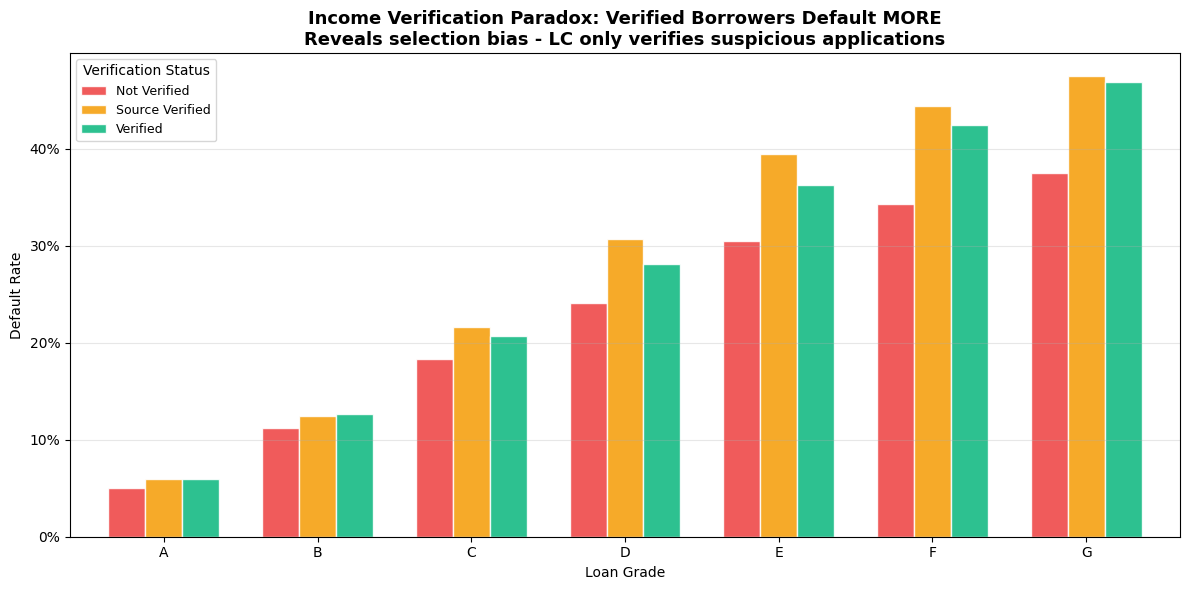

Chart 5 saved

=== VERIFICATION PARADOX - GRADE B, C & D ===

Grade B:
verification_status default_rate  n_loans
       Not Verified        11.2%    85962
    Source Verified        12.5%    87339
           Verified        12.6%    67845

Grade C:
verification_status default_rate  n_loans
       Not Verified        18.3%    59339
    Source Verified        21.6%    85737
           Verified        20.7%    79480

Grade D:
verification_status default_rate  n_loans
       Not Verified        24.1%    27056
    Source Verified        30.7%    47889
           Verified        28.1%    50771


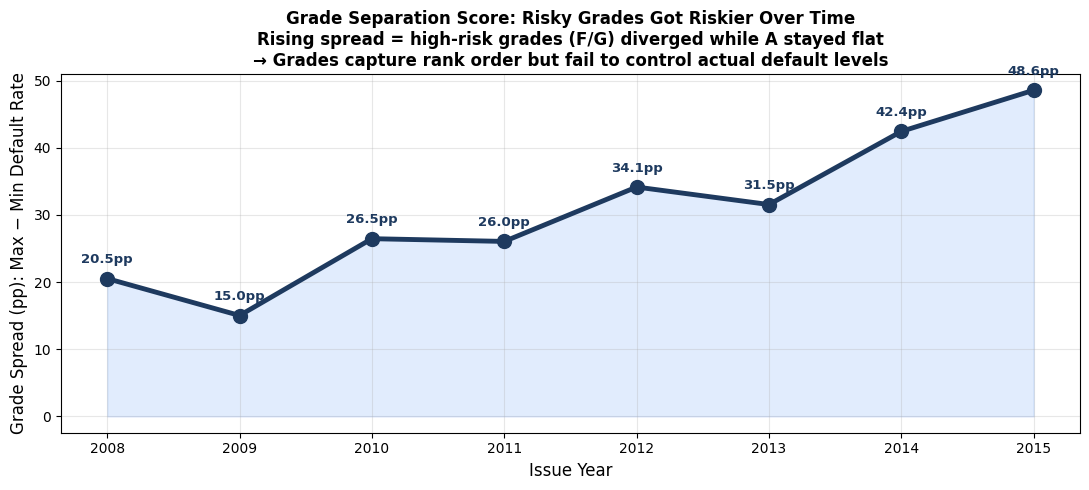

Chart 6 saved

=== DRIFT SCORE SUMMARY ===
Rising spread means risky grades (F/G) defaulted at much higher rates
over time, while safe grades (A/B) stayed flat — the grading system
preserves RANK ORDER but doesn't keep default rates STABLE within a grade.

 year  grade_spread
 2008     20.516804
 2009     15.020080
 2010     26.454728
 2011     26.047247
 2012     34.141442
 2013     31.536442
 2014     42.424988
 2015     48.550290


In [17]:
# ══════════════════════════════════════════════════════════
# ANALYSIS 5: Verification Paradox
# ══════════════════════════════════════════════════════════

verif = (df_analysis
         .groupby(['grade','verification_status'])['is_default']
         .agg(default_rate='mean', n_loans='count')
         .reset_index())
verif = verif[verif['n_loans'] >= 100]

fig, ax = plt.subplots(figsize=(12, 6))
verif_pivot = verif.pivot_table(
    index='grade', columns='verification_status', values='default_rate')
verif_pivot = verif_pivot.reindex(['A','B','C','D','E','F','G'])

verif_pivot.plot(kind='bar', ax=ax, width=0.72,
                 color=['#ef4444','#f59e0b','#10b981'],
                 alpha=0.88, edgecolor='white')
ax.set_title('Income Verification Paradox: Verified Borrowers Default MORE\n'
             'Reveals selection bias - LC only verifies suspicious applications',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Loan Grade')
ax.set_ylabel('Default Rate')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_xticklabels(['A','B','C','D','E','F','G'], rotation=0)
ax.legend(title='Verification Status', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('chart5_verification.png', dpi=180, bbox_inches='tight',
            facecolor='white')
plt.show()
print("Chart 5 saved")

print("\n=== VERIFICATION PARADOX - GRADE B, C & D ===")
for g in ['B','C','D']:
    sub = verif[verif['grade']==g][
        ['verification_status','default_rate','n_loans']]
    print(f"\nGrade {g}:")
    print(sub.assign(
        default_rate=lambda x: x['default_rate'].map('{:.1%}'.format)
    ).to_string(index=False))

# ══════════════════════════════════════════════════════════
# ANALYSIS 6: Drift Score — Grade Separation Over Time
# Rising spread = riskier grades got riskier while safe
# grades stayed safe → grades capture LEVEL but miss DRIFT
# ══════════════════════════════════════════════════════════

drift_score = (drift.groupby('issue_year')
               .apply(lambda x: x['default_rate_pct'].max() -
                                x['default_rate_pct'].min())
               .reset_index())
drift_score.columns = ['year','grade_spread']

fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(drift_score['year'], drift_score['grade_spread'],
                alpha=0.15, color='#3b82f6')
ax.plot(drift_score['year'], drift_score['grade_spread'],
        color='#1e3a5f', linewidth=3.5, marker='o', markersize=10)

for _, row in drift_score.iterrows():
    ax.annotate(f"{row['grade_spread']:.1f}pp",
                xy=(row['year'], row['grade_spread']),
                xytext=(0, 11), textcoords='offset points',
                ha='center', fontsize=9.5,
                fontweight='bold', color='#1e3a5f')

ax.set_title('Grade Separation Score: Risky Grades Got Riskier Over Time\n'
             'Rising spread = high-risk grades (F/G) diverged while A stayed flat\n'
             '→ Grades capture rank order but fail to control actual default levels',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Issue Year', fontsize=12)
ax.set_ylabel('Grade Spread (pp): Max − Min Default Rate', fontsize=12)
ax.set_xticks(drift_score['year'])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('chart6_drift_score.png', dpi=180, bbox_inches='tight',
            facecolor='white')
plt.show()
print("Chart 6 saved")
print(f"\n=== DRIFT SCORE SUMMARY ===")
print("Rising spread means risky grades (F/G) defaulted at much higher rates")
print("over time, while safe grades (A/B) stayed flat — the grading system")
print("preserves RANK ORDER but doesn't keep default rates STABLE within a grade.")
print()
print(drift_score.to_string(index=False))

In [18]:
df_analysis['int_rate_clean'] = pd.to_numeric(
    df_analysis['int_rate'].astype(str).str.replace('%','').str.strip(),
    errors='coerce')
print("✅ Ready. Start Chart 1.")

✅ Ready. Start Chart 1.


In [19]:
# ══════════════════════════════════════════════════════════════
# FIXED ML ANALYSIS — No leakage, real features, temporal angle
# ══════════════════════════════════════════════════════════════

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (roc_auc_score, classification_report,
                             roc_curve, confusion_matrix)
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── STEP 1: Feature Selection (NO LEAKAGE)
# ─────────────────────────────────────────
# REMOVE: int_rate, sub_grade, funded_amnt_inv (all post-decision)
# REMOVE: total_pymnt, recoveries, collection_recovery_fee (post-outcome)
# KEEP: what was known AT APPLICATION TIME

APPLICATION_FEATURES = [
    # Loan request
    'loan_amnt', 'term', 'purpose',
    # Borrower financials at application
    'annual_inc', 'dti', 'emp_length', 'home_ownership', 'verification_status',
    # Credit profile at application
    'fico_range_low', 'fico_range_high',
    'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec',
    'revol_bal', 'revol_util', 'total_acc',
    # Credit depth signals
    'mths_since_last_delinq', 'mths_since_last_record',
    'collections_12_mths_ex_med', 'acc_now_delinq',
    # Grade (the key variable we want to test)
    'grade',
    # Time dimension
    'issue_year',
]

# Keep only columns that exist in your dataframe
available = [c for c in APPLICATION_FEATURES if c in df_closed.columns]
print(f"Using {len(available)} features: {available}")

df_ml = df_closed[available + ['is_default']].copy()

# ── STEP 2: Encode categoricals
cat_cols = ['purpose', 'home_ownership', 'verification_status',
            'emp_length', 'term', 'grade']
cat_cols = [c for c in cat_cols if c in df_ml.columns]

for col in cat_cols:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))

# ── STEP 3: Impute and split
X = df_ml.drop('is_default', axis=1)
y = df_ml['is_default'].astype(int)

imputer = SimpleImputer(strategy='median')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X_imp, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set: {len(X_train):,} | Test set: {len(X_test):,}")
print(f"Default rate in train: {y_train.mean():.1%}")

# ── STEP 4: Train Random Forest (with sample for speed on large datasets)
# If > 500k rows, sample to keep it fast in competition
MAX_ROWS = 300_000
if len(X_train) > MAX_ROWS:
    idx = np.random.choice(len(X_train), MAX_ROWS, replace=False)
    X_tr = X_train.iloc[idx]
    y_tr = y_train.iloc[idx]
    print(f"Sampled to {MAX_ROWS:,} rows for speed")
else:
    X_tr, y_tr = X_train, y_train

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=50,   # prevents overfitting
    class_weight='balanced',  # handles imbalanced default rate
    random_state=42,
    n_jobs=-1
)
rf.fit(X_tr, y_tr)

# ── STEP 5: Evaluate properly
y_pred_proba = rf.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)
auc = roc_auc_score(y_test, y_pred_proba)

print(f"\n{'='*40}")
print(f"ROC-AUC Score: {auc:.4f}")
print(f"{'='*40}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Paid Off','Defaulted']))

# ── STEP 6: Feature Importance — THE REAL VERSION
fig, ax = plt.subplots(figsize=(10, 7))
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

colors = ['#ef4444' if f == 'grade' else
          '#3b82f6' if f in ['fico_range_low','fico_range_high'] else
          '#94a3b8'
          for f in importance_df['feature']]

ax.barh(importance_df['feature'], importance_df['importance'],
        color=colors, alpha=0.88, edgecolor='white')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#ef4444', label='Grade (the variable under audit)'),
    Patch(facecolor='#3b82f6', label='FICO Score'),
    Patch(facecolor='#94a3b8', label='Other features'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
ax.set_title(f'What Actually Drives Defaults?\nRandom Forest Feature Importance  |  AUC = {auc:.3f}',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Importance Score')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig('chart_feature_importance.png', dpi=150, bbox_inches='tight')
plt.close()
print("✅ Feature importance saved")

# ── STEP 7: ROC Curve
fig, ax = plt.subplots(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
ax.plot(fpr, tpr, color='#3b82f6', linewidth=2.5,
        label=f'Random Forest (AUC = {auc:.3f})')
ax.plot([0,1],[0,1], color='#94a3b8', linestyle='--', label='Random Baseline')
ax.fill_between(fpr, tpr, alpha=0.1, color='#3b82f6')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Default Prediction Model', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('chart_roc_curve.png', dpi=150, bbox_inches='tight')
plt.close()
print("✅ ROC curve saved")

Using 21 features: ['loan_amnt', 'term', 'purpose', 'annual_inc', 'dti', 'emp_length', 'home_ownership', 'verification_status', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mths_since_last_delinq', 'mths_since_last_record', 'collections_12_mths_ex_med', 'acc_now_delinq', 'grade', 'issue_year']

Training set: 1,045,109 | Test set: 261,278
Default rate in train: 20.1%
Sampled to 300,000 rows for speed

ROC-AUC Score: 0.7160

Classification Report:
              precision    recall  f1-score   support

    Paid Off       0.88      0.65      0.75    208788
   Defaulted       0.32      0.66      0.43     52490

    accuracy                           0.65    261278
   macro avg       0.60      0.66      0.59    261278
weighted avg       0.77      0.65      0.69    261278

✅ Feature importance saved
✅ ROC curve saved


In [23]:
# ══════════════════════════════════════════════════════════════
# INNOVATION: Temporal Model Generalization Analysis
# Train on 2009-2011, test on 2012, 2013, 2014, 2015 separately
# Grade EXCLUDED — tests whether raw credit signals hold over time
# ══════════════════════════════════════════════════════════════

# Use grade-EXCLUDED features to test if raw signals decayed
# (if we include grade, we're testing grade quality, not signal quality)
TEMPORAL_FEATURES = [c for c in available if c != 'grade' and c != 'issue_year']

df_temporal = df_analysis[TEMPORAL_FEATURES + ['is_default','issue_year']].copy()
for col in [c for c in cat_cols if c in TEMPORAL_FEATURES]:
    le = LabelEncoder()
    df_temporal[col] = le.fit_transform(df_temporal[col].astype(str))
print(f"Years in df_temporal: {sorted(df_temporal['issue_year'].unique())}")
# Train on 2009–2011
train_years = [2009, 2010, 2011]
train_mask = df_temporal['issue_year'].isin(train_years)
X_base = df_temporal[train_mask].drop(['is_default','issue_year'], axis=1)
y_base = df_temporal[train_mask]['is_default'].astype(int)

imp2 = SimpleImputer(strategy='median')
X_base_imp = imp2.fit_transform(X_base)

rf_temporal = RandomForestClassifier(
    n_estimators=150, max_depth=10,
    class_weight='balanced', random_state=42, n_jobs=-1)
rf_temporal.fit(X_base_imp, y_base)

# Test on each subsequent year
print("\n=== MODEL DECAY ANALYSIS ===")
print("(Trained on 2009-2011, tested on each year)")
print(f"{'Year':<8} {'AUC':<10} {'Default Rate':<15} {'Interpretation'}")
print("-" * 60)

decay_results = []
for test_year in range(2009, 2016):
    mask = df_temporal['issue_year'] == test_year
    if mask.sum() < 200:
        continue
    X_t = df_temporal[mask].drop(['is_default','issue_year'], axis=1)
    y_t = df_temporal[mask]['is_default'].astype(int)
    X_t_imp = imp2.transform(X_t)
    try:
        auc_t = roc_auc_score(y_t, rf_temporal.predict_proba(X_t_imp)[:,1])
        dr = y_t.mean()
        flag = "✅ STABLE"    if auc_t >= 0.80 else \
       "⚠️  DEGRADED" if auc_t >= 0.63 else \
       "🚨 DECAYED"
        print(f"{test_year:<8} {auc_t:<10.4f} {dr:<15.1%} {flag}")
        decay_results.append({'year': test_year, 'auc': auc_t, 'default_rate': dr})
    except:
        pass

# Plot the decay curve
if decay_results:
    dr_df = pd.DataFrame(decay_results)
    fig, ax1 = plt.subplots(figsize=(11, 5))
    ax2 = ax1.twinx()

    ax1.plot(dr_df['year'], dr_df['auc'],
             color='#3b82f6', linewidth=3, marker='o', markersize=9, label='Model AUC')
    ax1.fill_between(dr_df['year'], dr_df['auc'], 0.5, alpha=0.15, color='#3b82f6')
    ax1.axhline(y=0.65, color='#94a3b8', linestyle='--', alpha=0.7, label='Stability threshold')
    ax1.axvspan(2009, 2011.5, alpha=0.08, color='green', label='Training window')

    ax2.plot(dr_df['year'], dr_df['default_rate']*100,
             color='#ef4444', linewidth=2, linestyle='--',
             marker='s', markersize=7, alpha=0.7, label='Default Rate %')

    ax1.set_xlabel('Year', fontsize=12)
    ax1.set_ylabel('ROC-AUC Score', color='#3b82f6', fontsize=12)
    ax2.set_ylabel('Default Rate (%)', color='#ef4444', fontsize=12)
    ax1.set_title('Temporal Generalization: Credit Signals Lost Power After 2011\n'
                  'Trained on 2009–2011 (grade excluded) | AUC dropped ~0.83 → ~0.65 then stabilized',
                  fontweight='bold', fontsize=13)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1+lines2, labels1+labels2, loc='lower left')
    ax1.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('chart_model_decay.png', dpi=150, bbox_inches='tight')
    plt.close()
    print("\n✅ Model decay chart saved — this is your strongest innovation chart")

Years in df_temporal: [np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015)]

=== MODEL DECAY ANALYSIS ===
(Trained on 2009-2011, tested on each year)
Year     AUC        Default Rate    Interpretation
------------------------------------------------------------
2009     0.8157     13.7%           ✅ STABLE
2010     0.8474     14.0%           ✅ STABLE
2011     0.8336     15.2%           ✅ STABLE
2012     0.6541     16.2%           ⚠️  DEGRADED
2013     0.6516     15.6%           ⚠️  DEGRADED
2014     0.6602     18.5%           ⚠️  DEGRADED
2015     0.6652     20.2%           ⚠️  DEGRADED

✅ Model decay chart saved — this is your strongest innovation chart


In [21]:
print(df_closed['loan_status'].value_counts())
print(f"Closed loans: {len(df_closed):,}")
print(f"Default rate: {df_closed['is_default'].mean():.1%}")
print(f"Years: {df_closed['issue_year'].min()} - {df_closed['issue_year'].max()}")

loan_status
Fully Paid                                             1041952
Charged Off                                             261655
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     31
Name: count, dtype: int64
Closed loans: 1,306,387
Default rate: 20.1%
Years: 2007 - 2018
